# 03 — Static EDA

In [1]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks": ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.eda import plot_tenure_distribution, plot_contract_churn, plot_monthly_charges_boxplot, plot_correlation_heatmap

In [2]:
path = ROOT / "data" / "processed" / "final_dataset.csv"
df = pd.read_csv(path)
fig_dir = ROOT / "outputs" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)
print(df.shape)
display(df.head())

(7043, 59)


,CustomerID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Location ID,Country,...,Churn Score,CLTV,Churn Category,Churn Reason,Population,Tenure_Group,CLV_Estimated,Churn_Flag,Monthly Charge_Capped,Total Charges_Capped
0,8779-QRDMV,Male,78,No,Yes,No,No,0,OXCZEW7397,United States,...,91,5433,Competitor,Competitor offered more data,68701.0,<1 year,39.65,1,39.65,39.65
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,FCCECI8494,United States,...,69,5302,Competitor,Competitor made better offer,55668.0,<1 year,645.20,1,80.65,633.30
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,HEHUQY7254,United States,...,81,3179,Competitor,Competitor made better offer,47534.0,1-3 years,1718.10,1,95.45,1752.55
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,WIUHRF2613,United States,...,88,5337,Dissatisfaction,Limited range of services,27778.0,1-3 years,2462.50,1,98.50,2514.50
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,CFEZBF4415,United States,...,67,2793,Price,Extra data charges,26265.0,>3 years,2830.50,1,76.50,2868.15


In [3]:
plot_tenure_distribution(df, fig_dir / "01_tenure_by_churn.png")
plot_contract_churn(df, fig_dir / "02_churn_by_contract.png")
plot_monthly_charges_boxplot(df, fig_dir / "03_monthly_charge_boxplot.png")
plot_correlation_heatmap(df, fig_dir / "04_correlation_heatmap.png")
print("EDA figures saved to", fig_dir)

EDA figures saved to E:\TuongTacDuLieuTrucQuan\ProjectCuoiKy\telco_churn_project\outputs\figures


01_tenure_by_churn.png


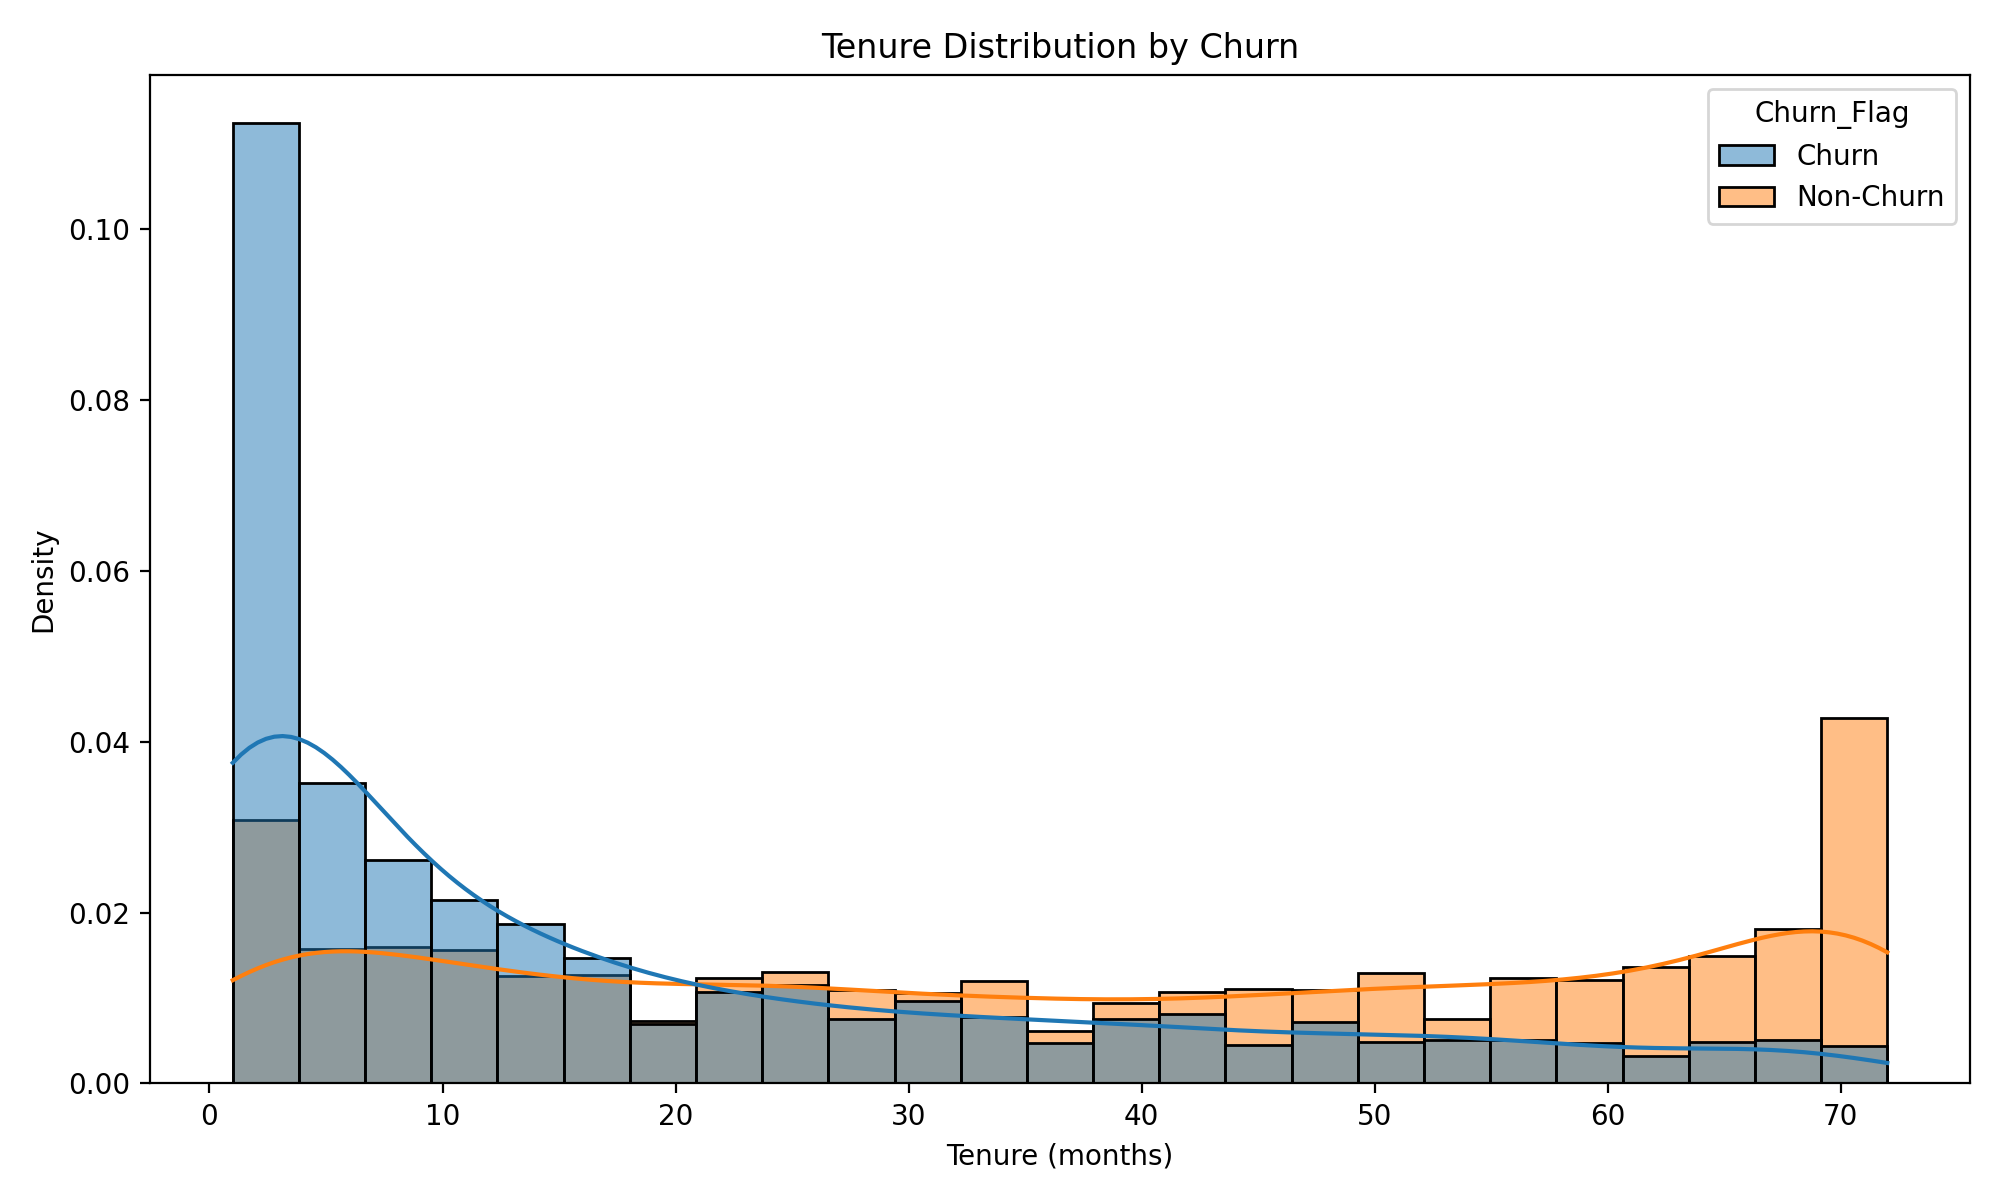

02_churn_by_contract.png


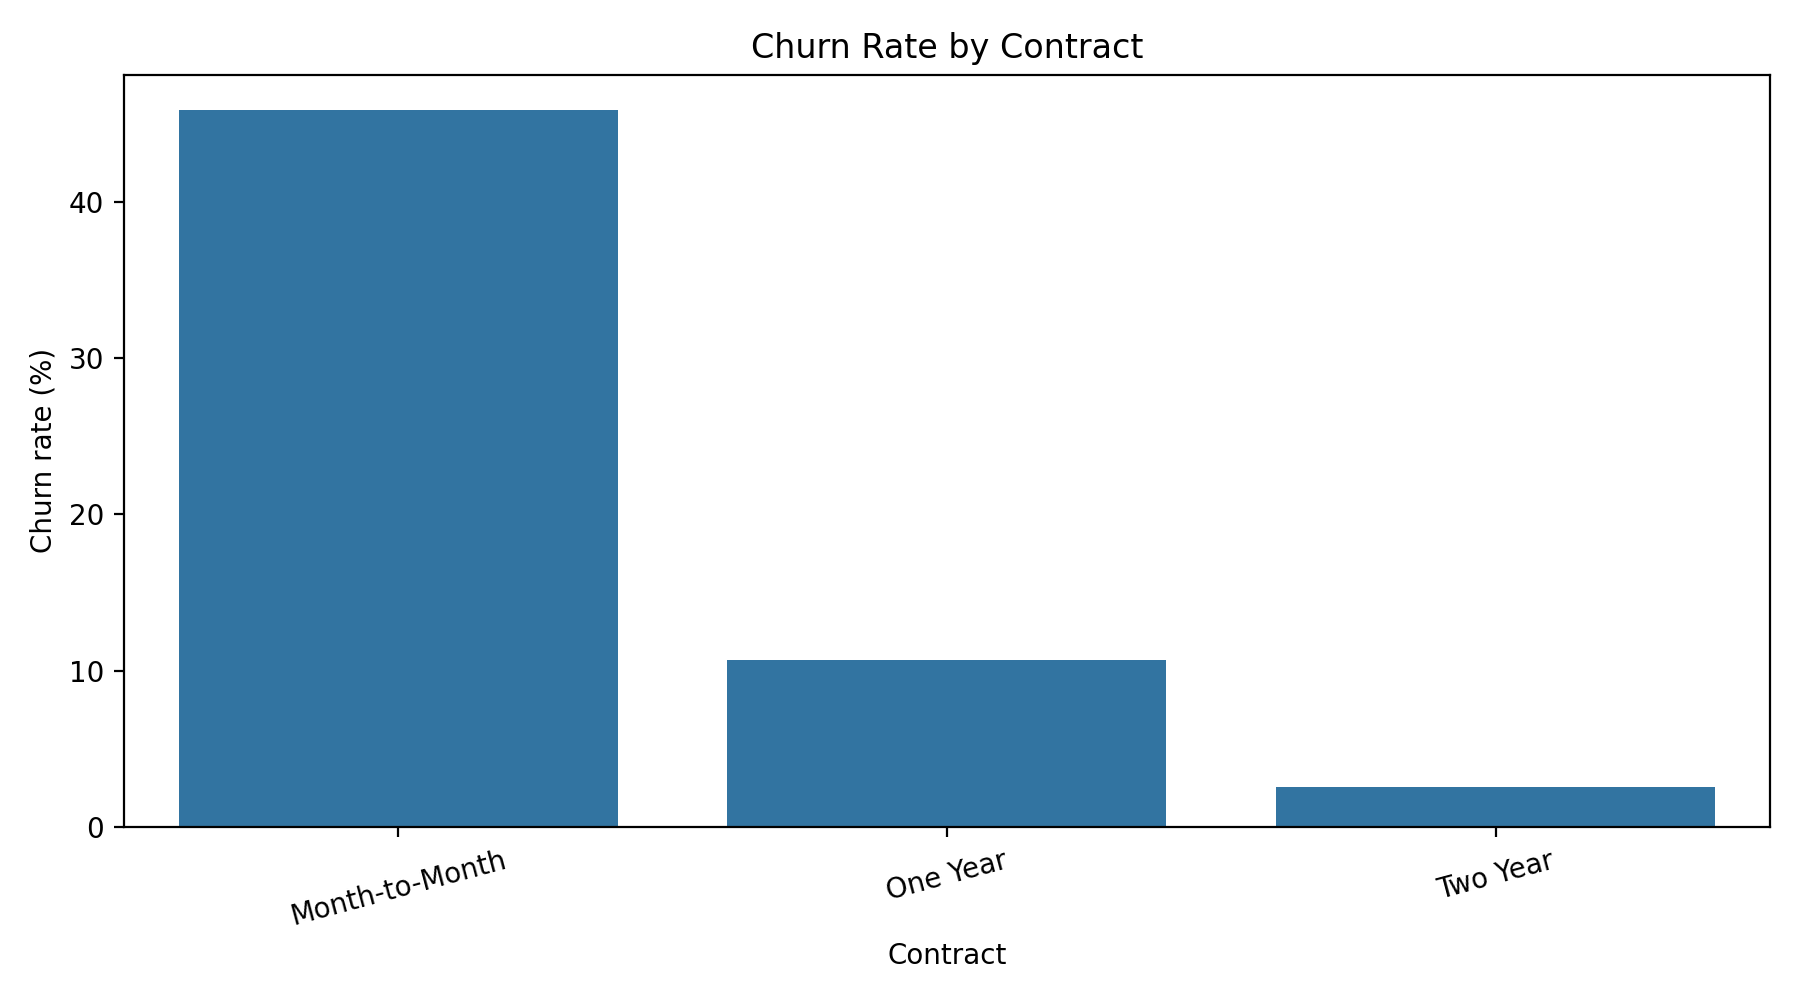

03_monthly_charge_boxplot.png


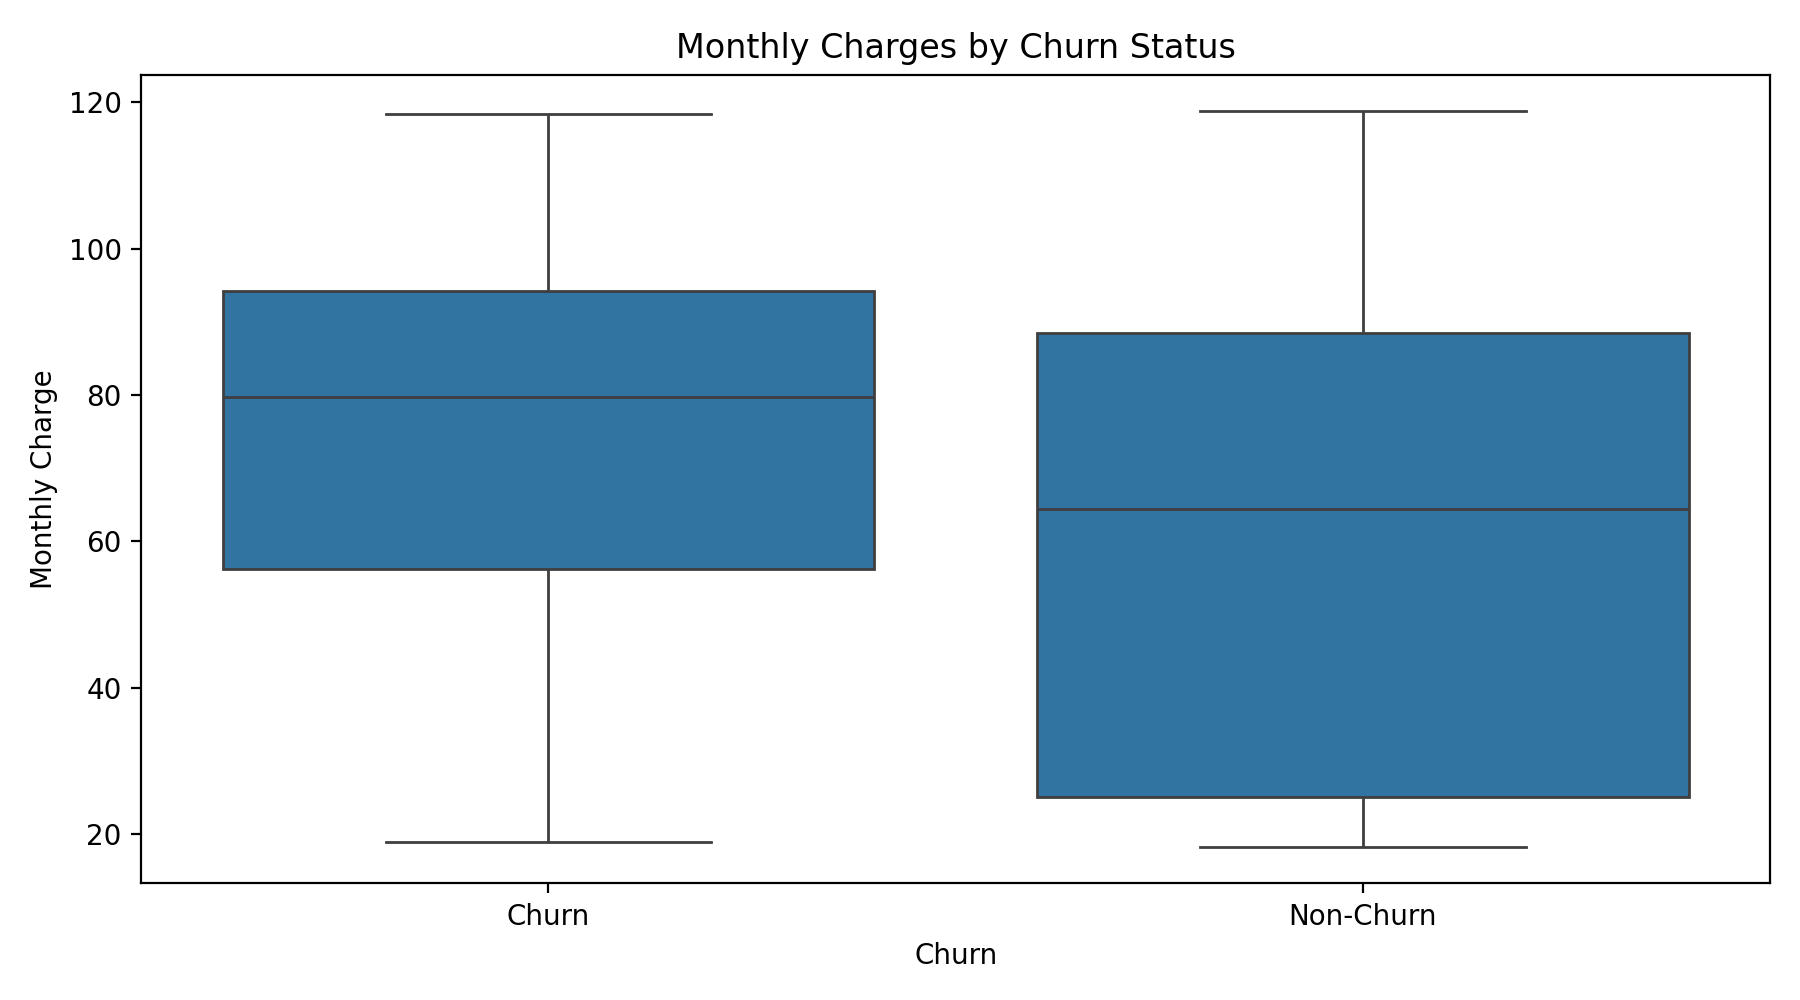

04_correlation_heatmap.png


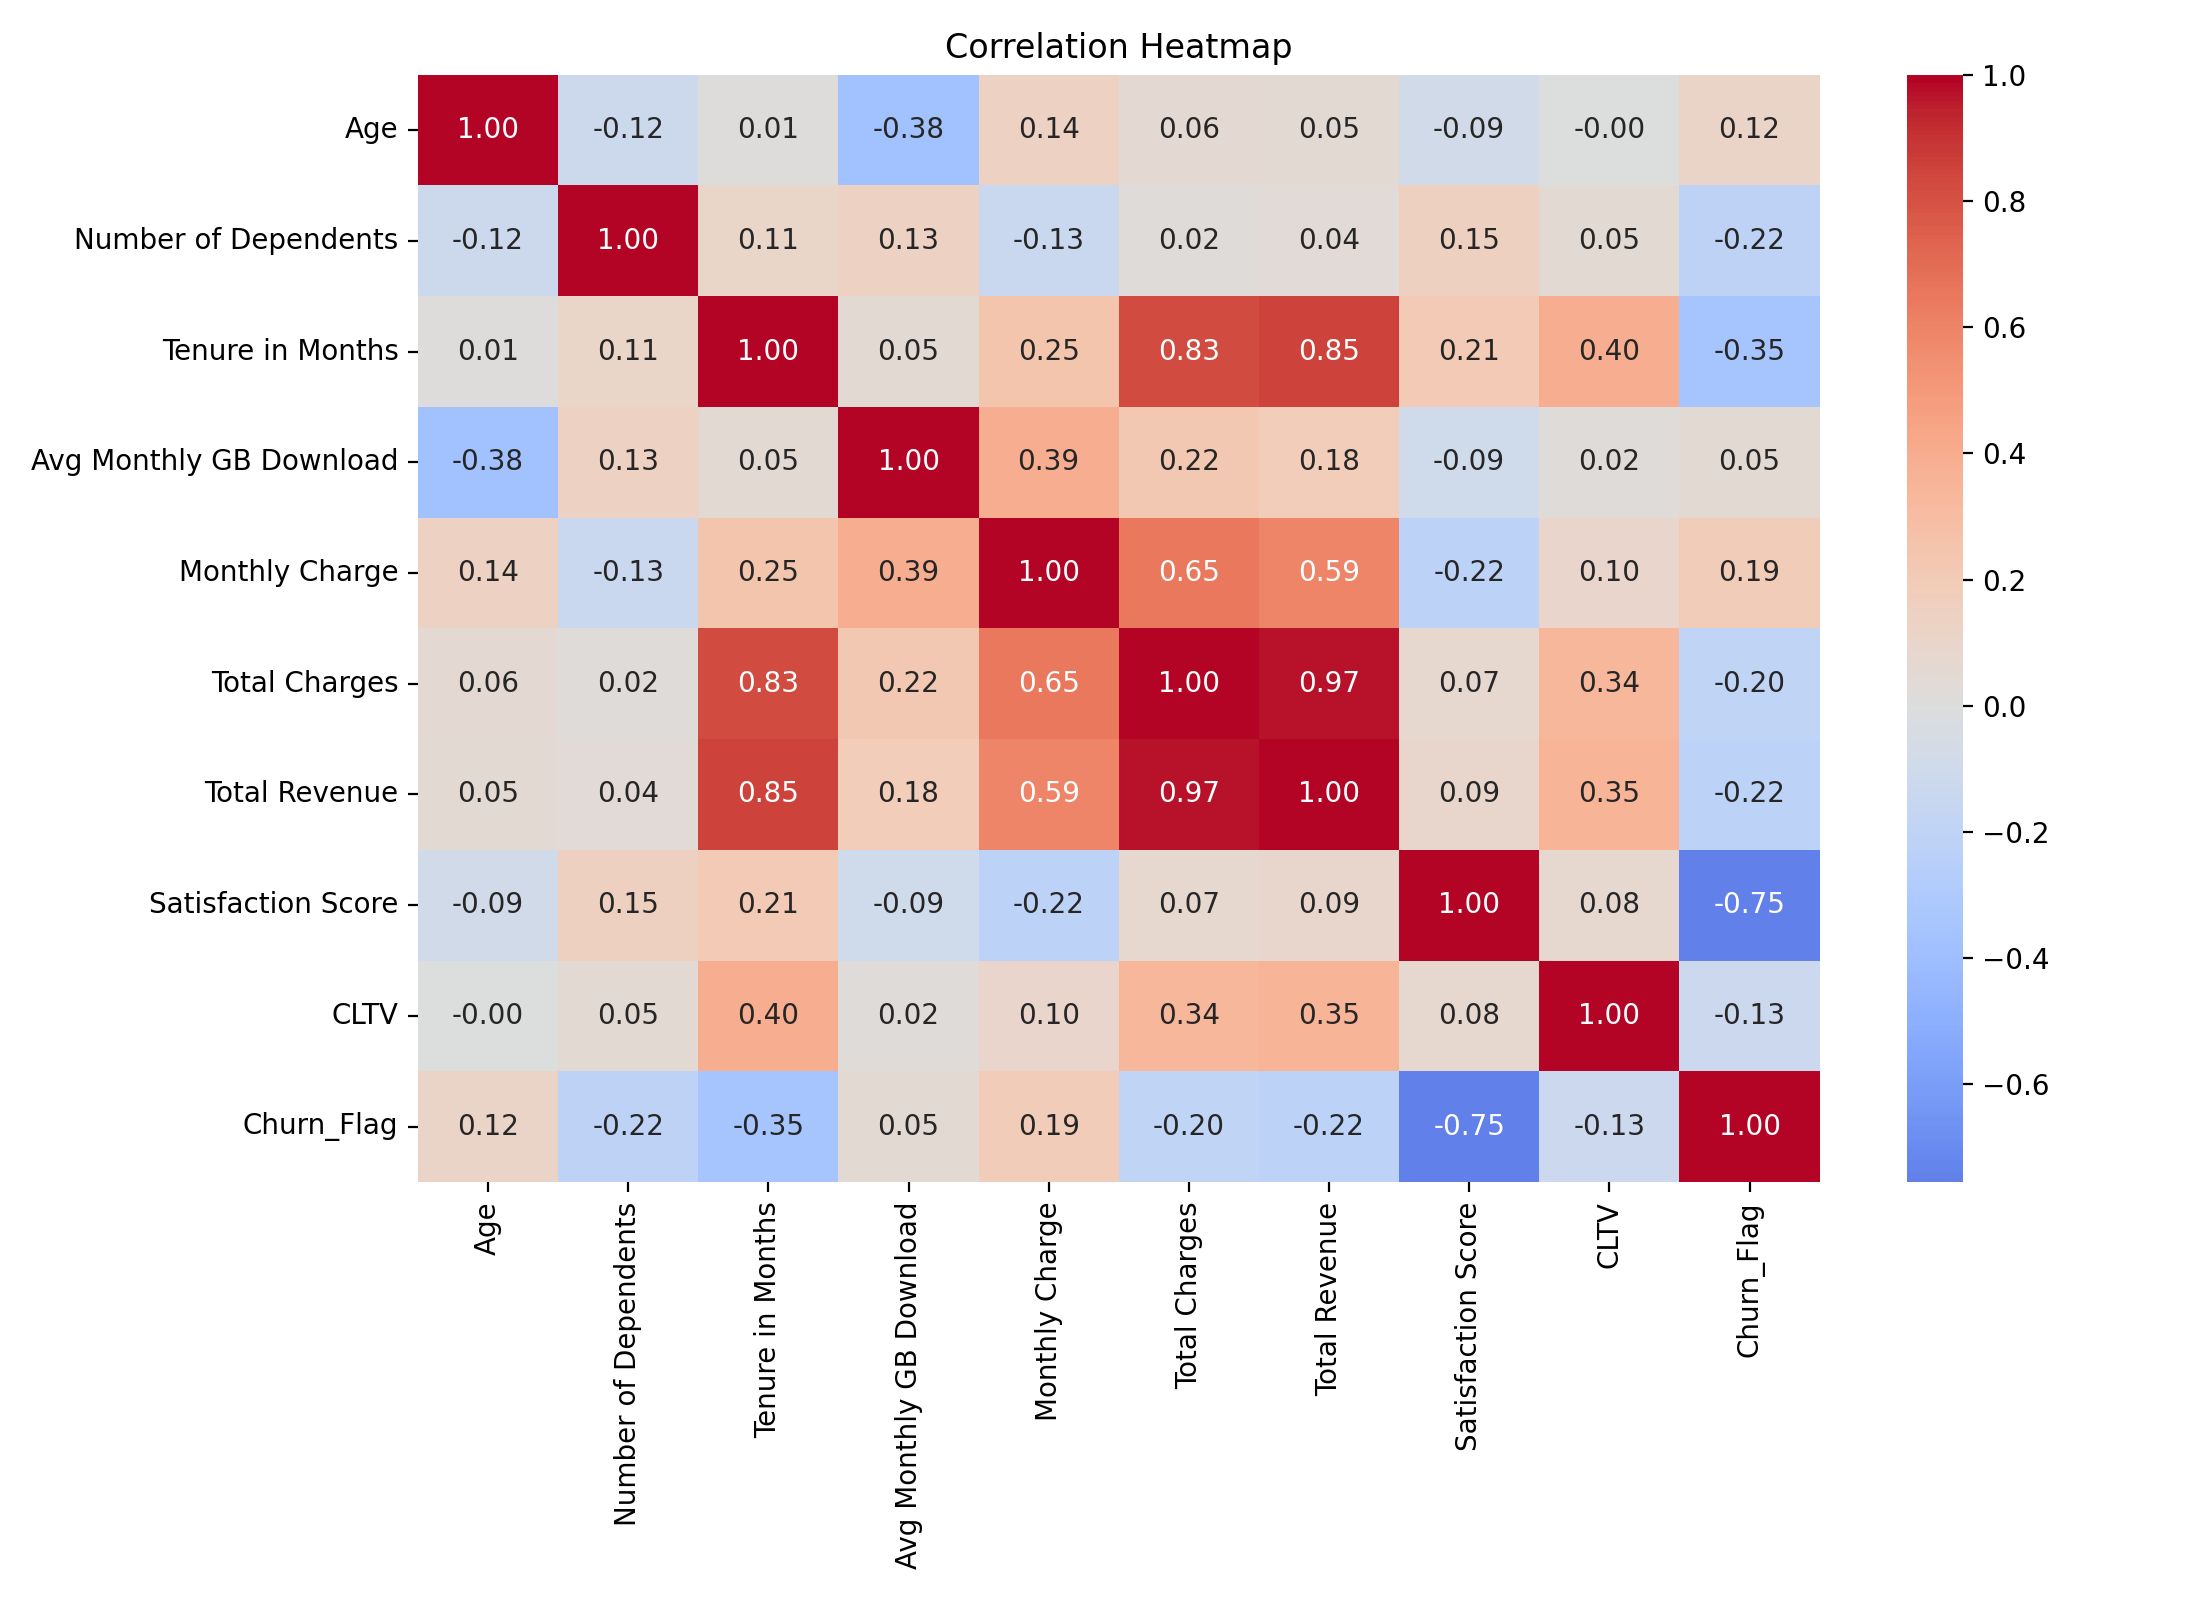

In [4]:
from IPython.display import Image, display
for name in ["01_tenure_by_churn.png", "02_churn_by_contract.png", "03_monthly_charge_boxplot.png", "04_correlation_heatmap.png"]:
    print(name)
    display(Image(filename=str(fig_dir / name), width=850))

1. Phân phối thời gian gắn bó (01_tenure_by_churn.png)   
- Kết quả quan sát: Tỷ lệ khách hàng rời bỏ (Churn) tập trung cao nhất ở giai đoạn đầu (đặc biệt trong 1–12 tháng đầu tiên). Đối với nhóm gắn bó lâu năm (trên 50–60 tháng), tỷ lệ Churn giảm xuống mức rất thấp.   
- Đánh giá nghiệp vụ: Giai đoạn mới bắt đầu sử dụng dịch vụ là thời điểm khách hàng dễ hủy dịch vụ nhất. Doanh nghiệp cần tập trung cải thiện trải nghiệm trải nghiệm người dùng mới (Onboarding) và hỗ trợ kỹ thuật trong 6 tháng đầu.
2. Tỷ lệ Churn theo loại hợp đồng (02_churn_by_contract.png)   
- Kết quả quan sát: Khách hàng dùng hợp đồng theo từng tháng (Month-to-month) có tỷ lệ Churn áp đảo hoàn toàn so với hợp đồng dài hạn (1 năm và 2 năm).   
- Đánh giá nghiệp vụ: Loại hợp đồng là đặc trưng (feature) có lực phân loại rất mạnh để dự báo Churn. Ràng buộc pháp lý và ưu đãi của hợp đồng dài hạn giúp giữ chân người dùng hiệu quả; doanh nghiệp nên tung các gói chính sách khuyến khích người dùng nâng cấp từ Month-to-month lên 1–2 năm.
3. Phân bố cước phí hàng tháng (03_monthly_charge_boxplot.png)   
- Kết quả quan sát: Nhóm khách hàng rời đi có mức cước phí hàng tháng trung vị (Monthly Charges) cao hơn rõ rệt so với nhóm khách hàng ở lại.   
- Đánh giá nghiệp vụ: Khách hàng chi trả mức phí cao có xu hướng nhạy cảm về giá hơn hoặc có kỳ vọng chất lượng dịch vụ cao hơn. Nếu không cảm nhận được giá trị tương xứng, họ dễ dàng chuyển sang đối thủ cạnh tranh.
4. Ma trận tương quan (04_correlation_heatmap.png)   
- Kết quả quan sát:Biến TotalCharges có tương quan thuận rất mạnh với cả Tenure và MonthlyCharges (do TotalCharges ~ Tenure X MonthlyCharges$).   Biến Tenure có tương quan âm tương đối rõ rệt với biến Churn.   
- Đánh giá kỹ thuật (Mô hình hóa): Xuất hiện hiện tượng đa cộng tuyến (Multicollinearity) giữa các biến tiền tệ và thời gian. Khi đưa vào các mô hình Machine Learning (đặc biệt là Logistic Regression), cần xem xét loại bỏ hoặc biến đổi (Feature Engineering) biến TotalCharges để tránh gây nhiễu trọng số mô hình.

EDA chỉ mô tả quan sát/association. Không viết kết luận nhân quả kiểu “X gây churn” nếu chưa có thiết kế nhân quả phù hợp.